In [ ]:
import numpy as np
import functions.quantile as quantile
import matplotlib.pyplot as plt
import os

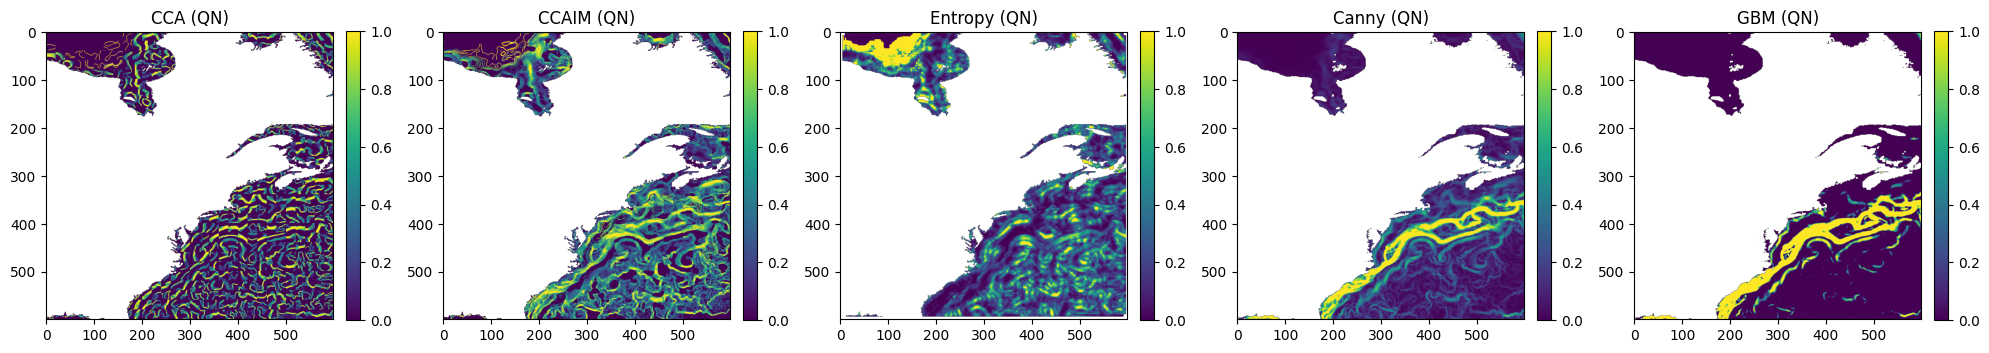

In [ ]:
# 1. Quantile Normalization of the matrices
region = '03'
path = os.path.join('./data/regions', region)

cca_matrix = np.load(os.path.join(path, 'cca.npy'))
ccaim_matrix = np.load(os.path.join(path, 'ccaim.npy'))
entropy_matrix = np.load(os.path.join(path, 'entropy.npy'))
canny_matrix = np.load(os.path.join(path, 'canny.npy'))
gbm_matrix = np.load(os.path.join(path, 'gbm.npy'))

cca_qn = quantile.quantile_normalize(cca_matrix)
ccaim_qn = quantile.quantile_normalize(ccaim_matrix)
entropy_qn = quantile.quantile_normalize(entropy_matrix)
canny_qn = quantile.quantile_normalize(canny_matrix)
gbm_qn = quantile.quantile_normalize(gbm_matrix)

plt.figure(figsize=(20, 4))
plt.subplot(1, 5, 1)
plt.imshow(np.flipud(cca_qn), cmap='viridis')
plt.title('CCA (QN)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1, 5, 2)
plt.imshow(np.flipud(ccaim_qn), cmap='viridis')
plt.title('CCAIM (QN)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1, 5, 3)
plt.imshow(np.flipud(entropy_qn), cmap='viridis')
plt.title('Entropy (QN)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1, 5, 4)
plt.imshow(np.flipud(canny_qn), cmap='viridis')
plt.title('Canny (QN)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1, 5, 5)
plt.imshow(np.flipud(gbm_qn), cmap='viridis')
plt.title('GBM (QN)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

C:\Users\codeAI\AppData\Local\Temp\ipykernel_34820\2811040648.py:1: RuntimeWarning: Mean of empty slice
  data_mean = np.nanmean([cca_qn, ccaim_qn, entropy_qn, canny_qn, gbm_qn], axis=0, dtype=np.float32)


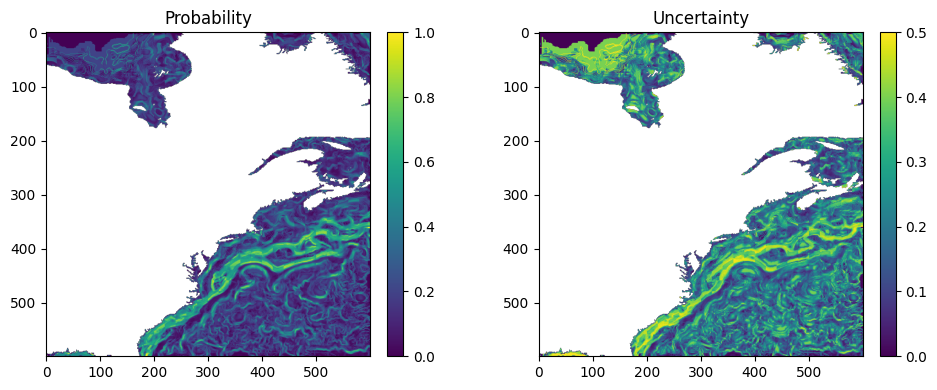

In [4]:
data_mean = np.nanmean([cca_qn, ccaim_qn, entropy_qn, canny_qn, gbm_qn], axis=0, dtype=np.float32)
data_std = np.nanstd([cca_qn, ccaim_qn, entropy_qn, canny_qn, gbm_qn], axis=0, dtype=np.float32)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(np.flipud(data_mean), cmap='viridis')
plt.title('Probability')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1, 2, 2)
plt.imshow(np.flipud(data_std), cmap='viridis')
plt.title('Uncertainty')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [5]:
# batch processing for all regions
regions = [f'{i:02d}' for i in range(1, 45)]

for region in regions:
    path = os.path.join('./data/regions', region)

    cca_matrix = np.load(os.path.join(path, 'cca.npy'))
    ccaim_matrix = np.load(os.path.join(path, 'ccaim.npy'))
    entropy_matrix = np.load(os.path.join(path, 'entropy.npy'))
    canny_matrix = np.load(os.path.join(path, 'canny.npy'))
    gbm_matrix = np.load(os.path.join(path, 'gbm.npy'))

    cca_qn = quantile.quantile_normalize(cca_matrix)
    ccaim_qn = quantile.quantile_normalize(ccaim_matrix)
    entropy_qn = quantile.quantile_normalize(entropy_matrix)
    canny_qn = quantile.quantile_normalize(canny_matrix)
    gbm_qn = quantile.quantile_normalize(gbm_matrix)

    data_mean = np.nanmean([cca_qn, ccaim_qn, entropy_qn, canny_qn, gbm_qn], axis=0, dtype=np.float32)
    data_std = np.nanstd([cca_qn, ccaim_qn, entropy_qn, canny_qn, gbm_qn], axis=0, dtype=np.float32)

    np.save(os.path.join(path, 'probability.npy'), data_mean)
    np.save(os.path.join(path, 'uncertainty.npy'), data_std)

C:\Users\codeAI\AppData\Local\Temp\ipykernel_34820\4023618236.py:19: RuntimeWarning: Mean of empty slice
  data_mean = np.nanmean([cca_qn, ccaim_qn, entropy_qn, canny_qn, gbm_qn], axis=0, dtype=np.float32)
